---
# 1. Importando Bibliotecas

In [2]:
import pandas as pd
import scipy as scp
from scipy import optimize
from scipy.optimize import curve_fit
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

In [3]:
path_to_data = Path.cwd().parent / "Dados"
target = path_to_data / "Dados_USP.xlsx"

if not target.exists():
    raise SystemExit("Arquivo não encontrado")

df_raw = pd.read_excel(target,skiprows=1,sheet_name="Ajustes")
df_raw.head(2)

,Grupo,Nome,1km_23-abr,2km_16-abr,Pace 2km_16-abr,3km_21-abr,Pace 3km,1km pós 21km_z1_25-abr,% Piora do pace z1,1km_21-mai,...,Pace 42km,Volume 8 semanas (Km),Meta (Km),% realização dos treinos proposto,z1 (Km),z2 (Km),z3 (Km),%z1,%z2,%z3
0,1,S1,00:04:25,00:09:55,00:04:57.500000,00:15:27,00:05:09,00:05:03,0.143396,00:04:38,...,00:06:07.190000,406,408.0,99.509804,322,26,58,79.310345,6.403941,14.285714
1,1,S2,00:04:18,00:08:48,00:04:24,00:13:30,00:04:30,00:04:34,0.062016,00:04:09,...,00:05:20.095000,407,408.0,99.754902,323,26,58,79.361179,6.388206,14.250614


In [4]:
df = df_raw.copy()
df.columns

Index(['Grupo', 'Nome', '1km_23-abr', '2km_16-abr', 'Pace 2km_16-abr',
       '3km_21-abr', 'Pace 3km', '1km pós 21km_z1_25-abr',
       '% Piora do pace z1', '1km_21-mai', '21km_24-mai', 'Pace 21km',
       'Tempo dos 42km estimado com base no 21', 'Resultado da previsão',
       'Proporção entre tempo estimado e real', '1km pós 21km_TT_24-mai',
       '% Piora do pace TT', '42km', 'Pace 42km', 'Volume 8 semanas (Km)',
       'Meta (Km)', '% realização dos treinos proposto', 'z1 (Km)', 'z2 (Km)',
       'z3 (Km)', '%z1', '%z2', '%z3'],
      dtype='object')

In [5]:
colunas_tempo = [
    '1km_23-abr', '2km_16-abr', 'Pace 2km_16-abr', '3km_21-abr', 'Pace 3km',
    '1km pós 21km_z1_25-abr', '1km_21-mai', '21km_24-mai', 'Pace 21km',
    'Tempo dos 42km estimado com base no 21', '1km pós 21km_TT_24-mai',
    '42km', 'Pace 42km',
]

for col in colunas_tempo:
    df[col] = pd.to_timedelta(df[col].astype(str), errors="coerce")

---
# 2. Cluster

In [6]:
# 1. Defina o nome exato das colunas
col_tempo_real = "42km" 
col_tempo_estimado = "Tempo dos 42km estimado com base no 21"

# 2. Forçando a conversão para tempo (timedelta) ignorando textos inválidos
df[col_tempo_real] = pd.to_timedelta(df[col_tempo_real].astype(str), errors='coerce')
df[col_tempo_estimado] = pd.to_timedelta(df[col_tempo_estimado].astype(str), errors='coerce')

# 3. Agora extraímos os minutos com o .dt com segurança
df["tempo_42_real_min"] = df[col_tempo_real].dt.total_seconds() / 60
df["tempo_42_estimado_min"] = df[col_tempo_estimado].dt.total_seconds() / 60

# 4. Visualizando o resultado
df[["Nome", col_tempo_real, "tempo_42_real_min", col_tempo_estimado, "tempo_42_estimado_min"]].head()

,Nome,42km,tempo_42_real_min,Tempo dos 42km estimado com base no 21,tempo_42_estimado_min
0,S1,0 days 04:17:02,257.033333,0 days 04:03:32,243.533333
1,S2,0 days 03:44:04,224.066667,0 days 03:16:38,196.633333
2,S3,0 days 04:08:30,248.500000,0 days 03:54:42,234.700000
3,S4,0 days 03:00:28,180.466667,0 days 02:48:48,168.800000
4,S5,0 days 04:04:19,244.316667,0 days 03:42:18,222.300000


In [7]:
centros_clusters = {
    "A — 3h00 ± 10 min": 180,
    "B — 3h20 ± 10 min": 200,
    "C — 3h40 ± 10 min": 220,
    "D — 4h00 ± 10 min": 240,
    "E — 4h20 ± 10 min": 260
}

def classificar_cluster(tempo_real_min, tempo_estimado_min):
    if pd.isna(tempo_real_min):
        return np.nan

    centros = np.array(list(centros_clusters.values()))
    nomes = list(centros_clusters.keys())

    # Distância do tempo real até cada centro
    distancias_real = np.abs(centros - tempo_real_min)

    # Centro mais próximo usando o tempo real
    menor_distancia = distancias_real.min()
    candidatos = np.where(distancias_real == menor_distancia)[0]

    # Caso normal: há apenas um cluster mais próximo
    if len(candidatos) == 1:
        return nomes[candidatos[0]]

    # Caso de fronteira: por exemplo, exatamente 3h10, 3h30 etc.
    if not pd.isna(tempo_estimado_min):
        distancias_estimado = np.abs(centros[candidatos] - tempo_estimado_min)
        vencedor = candidatos[np.argmin(distancias_estimado)]
        return nomes[vencedor]

    # Caso não exista estimativa: escolhe o cluster mais rápido
    return nomes[candidatos[0]]

In [8]:
df["cluster_42km"] = df.apply(
    lambda linha: classificar_cluster(
        linha["tempo_42_real_min"],
        linha["tempo_42_estimado_min"]
    ),
    axis=1
)

# Tabela organizada pelo tempo real
df[["Nome", "Grupo", col_tempo_real, col_tempo_estimado, "tempo_42_real_min", "cluster_42km"]].sort_values("tempo_42_real_min").head(15)

,Nome,Grupo,42km,Tempo dos 42km estimado com base no 21,tempo_42_real_min,cluster_42km
12,S13,1,0 days 02:56:58,0 days 02:39:46,176.966667,A — 3h00 ± 10 min
13,S14,1,0 days 02:58:12,0 days 02:47:42,178.200000,A — 3h00 ± 10 min
3,S4,1,0 days 03:00:28,0 days 02:48:48,180.466667,A — 3h00 ± 10 min
9,S10,1,0 days 03:03:43,0 days 02:56:18,183.716667,A — 3h00 ± 10 min
22,P8,2,0 days 03:07:38,0 days 02:52:50,187.633333,A — 3h00 ± 10 min
10,S11,1,0 days 03:08:41,0 days 02:59:30,188.683333,A — 3h00 ± 10 min
24,P10,2,0 days 03:10:29,0 days 02:59:10,190.483333,B — 3h20 ± 10 min
8,S9,1,0 days 03:10:38,0 days 03:02:40,190.633333,B — 3h20 ± 10 min
6,S7,1,0 days 03:15:29,0 days 02:59:32,195.483333,B — 3h20 ± 10 min
14,S15,1,0 days 03:25:45,0 days 03:15:44,205.750000,B — 3h20 ± 10 min


In [9]:
df["cluster_42km"] = df.apply(
    lambda linha: classificar_cluster(
        linha["tempo_42_real_min"],
        linha["tempo_42_estimado_min"]
    ),
    axis=1
)


df[["Nome", "Grupo", col_tempo_real, col_tempo_estimado, "tempo_42_real_min", "cluster_42km"]].sort_values("tempo_42_real_min").head(15)

,Nome,Grupo,42km,Tempo dos 42km estimado com base no 21,tempo_42_real_min,cluster_42km
12,S13,1,0 days 02:56:58,0 days 02:39:46,176.966667,A — 3h00 ± 10 min
13,S14,1,0 days 02:58:12,0 days 02:47:42,178.200000,A — 3h00 ± 10 min
3,S4,1,0 days 03:00:28,0 days 02:48:48,180.466667,A — 3h00 ± 10 min
9,S10,1,0 days 03:03:43,0 days 02:56:18,183.716667,A — 3h00 ± 10 min
22,P8,2,0 days 03:07:38,0 days 02:52:50,187.633333,A — 3h00 ± 10 min
10,S11,1,0 days 03:08:41,0 days 02:59:30,188.683333,A — 3h00 ± 10 min
24,P10,2,0 days 03:10:29,0 days 02:59:10,190.483333,B — 3h20 ± 10 min
8,S9,1,0 days 03:10:38,0 days 03:02:40,190.633333,B — 3h20 ± 10 min
6,S7,1,0 days 03:15:29,0 days 02:59:32,195.483333,B — 3h20 ± 10 min
14,S15,1,0 days 03:25:45,0 days 03:15:44,205.750000,B — 3h20 ± 10 min


In [10]:
# Contagem de corredores por Cluster
print("Contagem de alunos por cluster:")
display(df["cluster_42km"].value_counts(dropna=False))

# Verificando se alguém fugiu muito da faixa de tempo esperada
fora_da_faixa = df[
    (df["tempo_42_real_min"] < 170) |
    (df["tempo_42_real_min"] > 270)
]

print("\nCorredores muito fora da faixa:")
display(fora_da_faixa[["Nome", col_tempo_real, "tempo_42_real_min", "cluster_42km"]])

Contagem de alunos por cluster:


cluster_42km
E — 4h20 ± 10 min    7
C — 3h40 ± 10 min    7
A — 3h00 ± 10 min    6
B — 3h20 ± 10 min    5
D — 4h00 ± 10 min    4
Name: count, dtype: int64


Corredores muito fora da faixa:


,Nome,42km,tempo_42_real_min,cluster_42km


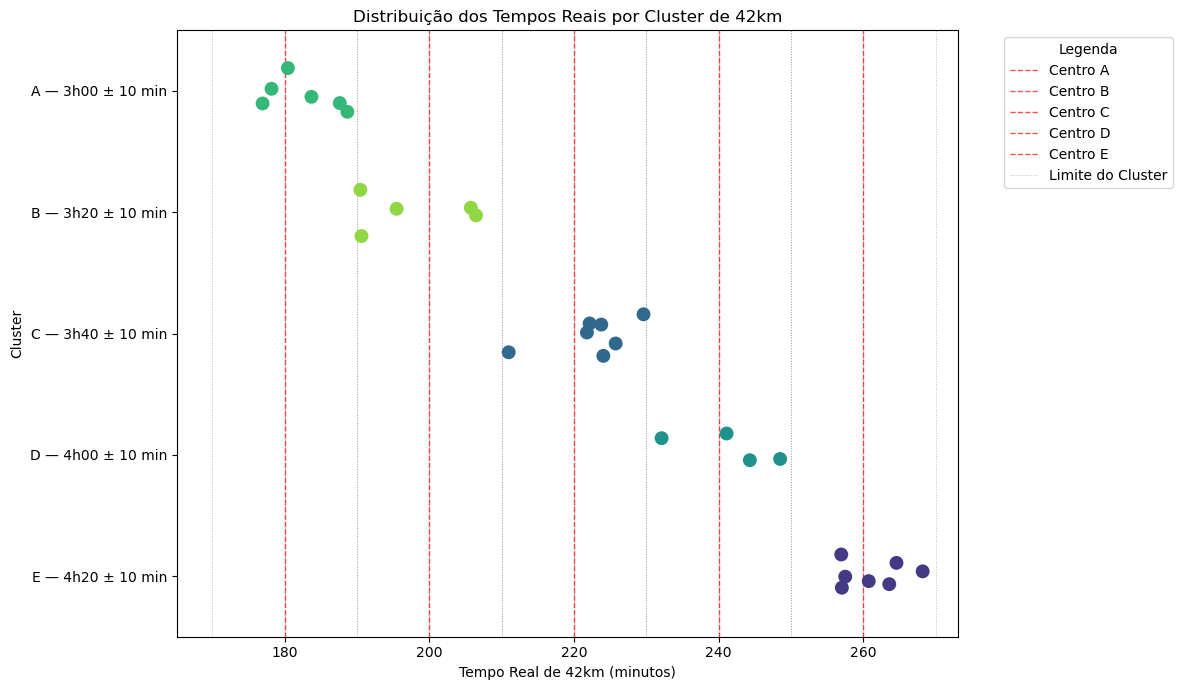

In [11]:
# Organizando os clusters para manter a ordem cronológica no gráfico
cluster_order = list(centros_clusters.keys())

plt.figure(figsize=(12, 7))
sns.stripplot(
    data=df,
    x="tempo_42_real_min",
    y="cluster_42km",
    order=cluster_order, # Set the order of clusters on y-axis
    jitter=0.2,
    hue="cluster_42km", # Color points by cluster
    palette="viridis",
    s=10,
    legend=False 
)

# Adicionando as linhas verticais para demarcar os limites e centros
legend_handles = []
legend_labels = []

for cluster_name, center_min in centros_clusters.items():
    # Linha principal do centro
    line_center = plt.axvline(center_min, color='red', linestyle='--', linewidth=1, alpha=0.7)
    
    # Limites das faixas (±10 min)
    line_bound_minus = plt.axvline(center_min - 10, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
    line_bound_plus = plt.axvline(center_min + 10, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)

    # Montando a legenda sem duplicar entradas
    nome_legend = f'Centro {cluster_name.split("—")[0].strip()}'
    if nome_legend not in legend_labels:
        legend_handles.append(line_center)
        legend_labels.append(nome_legend)

# Inserindo um marcador geral para a linha de limite na legenda
if 'Limite do Cluster' not in legend_labels:
    legend_handles.append(line_bound_minus) 
    legend_labels.append('Limite do Cluster')

plt.title('Distribuição dos Tempos Reais por Cluster de 42km')
plt.xlabel('Tempo Real de 42km (minutos)')
plt.ylabel('Cluster')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(legend_handles, legend_labels, title='Legenda', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# EDA

In [12]:
colunas_gerais = [
    "Volume 8 semanas (Km)",
    "Meta (Km)",
    "% realização dos treinos proposto",
    "z1 (Km)", "z2 (Km)", "z3 (Km)",
    "%z1", "%z2", "%z3",
    "tempo_42_real_min",
]
df[colunas_gerais].describe().round(2)


,Volume 8 semanas (Km),Meta (Km),% realização dos treinos proposto,z1 (Km),z2 (Km),z3 (Km),%z1,%z2,%z3,tempo_42_real_min
count,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00
mean,422.59,443.84,95.08,327.90,52.14,42.55,77.48,12.52,9.93,221.98
std,65.05,54.05,7.60,54.89,27.03,18.21,4.13,6.52,3.64,30.10
min,306.00,408.00,75.00,231.00,22.00,9.00,68.96,5.04,1.94,176.97
25%,388.00,408.00,91.01,290.00,26.00,28.00,73.53,6.47,7.27,190.63
50%,407.00,408.00,97.55,323.00,42.00,38.00,79.10,8.24,7.90,223.78
75%,477.00,523.00,100.00,384.00,79.00,58.00,79.92,19.30,13.74,248.50
max,527.00,523.00,113.48,418.00,105.00,74.00,86.10,23.58,14.51,268.20


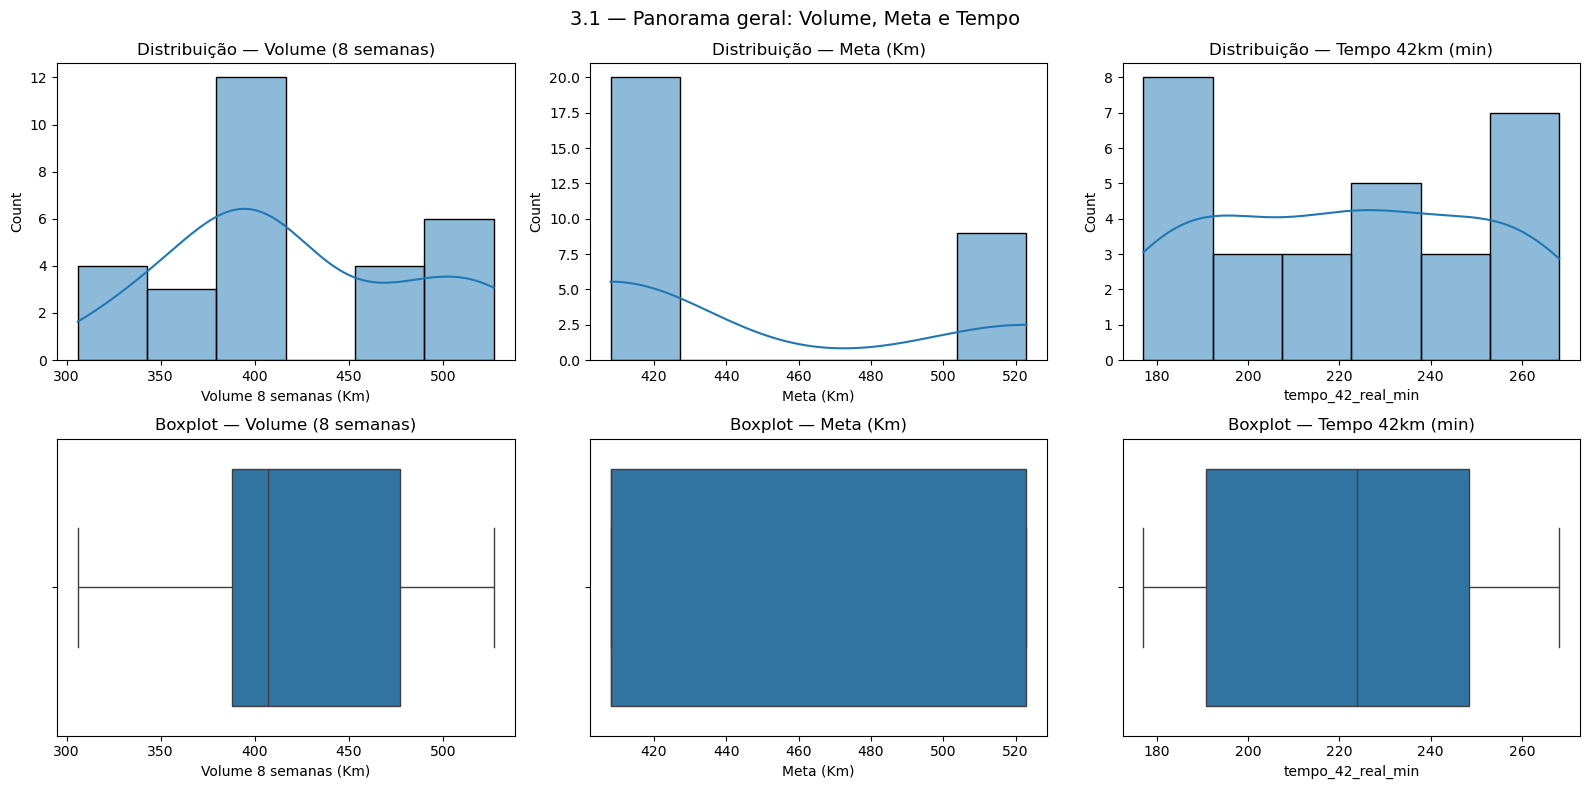

In [13]:
fig, axs = plt.subplots(2, 3, figsize=(16, 8))

cols_plot = ["Volume 8 semanas (Km)", "Meta (Km)", "tempo_42_real_min"]
titulos   = ["Volume (8 semanas)", "Meta (Km)", "Tempo 42km (min)"]

for j, (col, tit) in enumerate(zip(cols_plot, titulos)):
    sns.histplot(df[col], kde=True, ax=axs[0][j])
    axs[0][j].set_title(f"Distribuição — {tit}")

    sns.boxplot(x=df[col], ax=axs[1][j])
    axs[1][j].set_title(f"Boxplot — {tit}")

fig.suptitle("3.1 — Panorama geral: Volume, Meta e Tempo", fontsize=14)
fig.tight_layout()
plt.show()


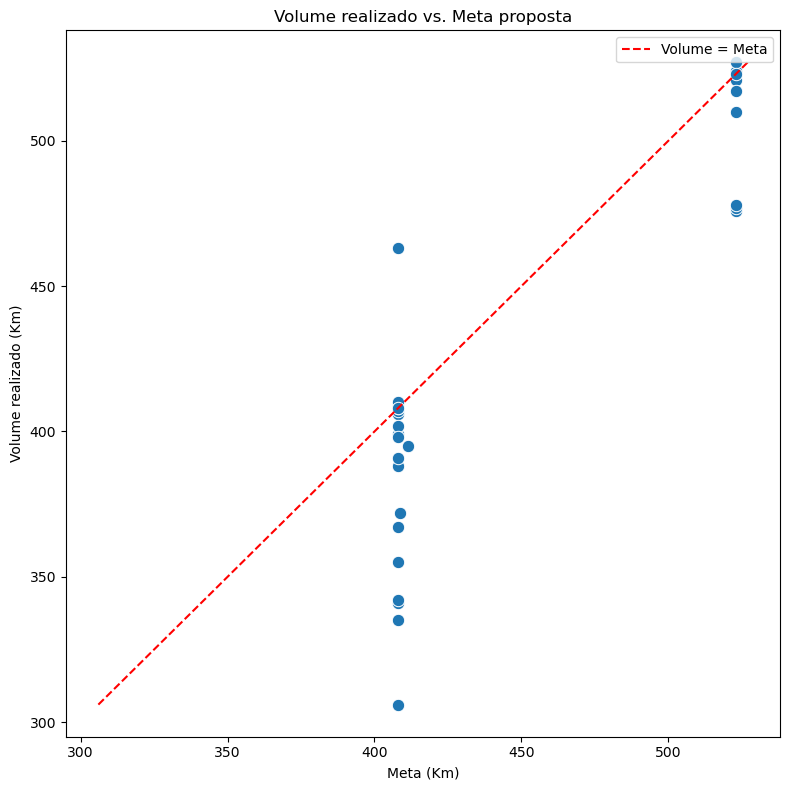

In [14]:
plt.figure(figsize=(8, 8))

sns.scatterplot(data=df, x="Meta (Km)", y="Volume 8 semanas (Km)", s=80)

lim_min = min(df["Meta (Km)"].min(), df["Volume 8 semanas (Km)"].min())
lim_max = max(df["Meta (Km)"].max(), df["Volume 8 semanas (Km)"].max())
plt.plot([lim_min, lim_max], [lim_min, lim_max],
         color="red", linestyle="--", label="Volume = Meta")

plt.title("Volume realizado vs. Meta proposta")
plt.xlabel("Meta (Km)")
plt.ylabel("Volume realizado (Km)")
plt.legend()
plt.tight_layout()
plt.show()


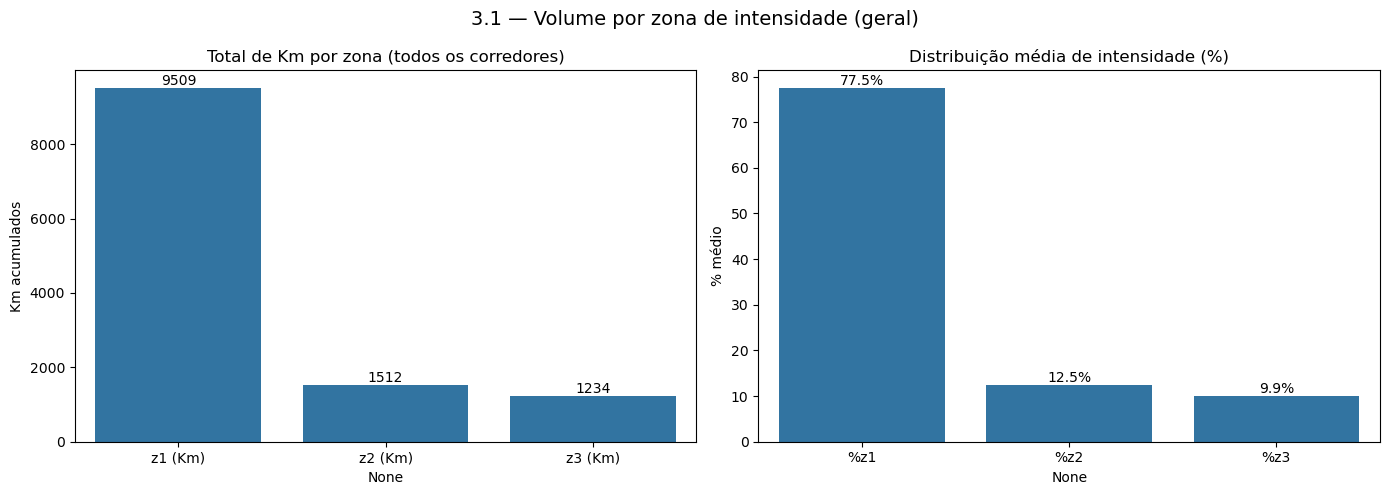

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

totais_km = df[["z1 (Km)", "z2 (Km)", "z3 (Km)"]].sum()
sns.barplot(x=totais_km.index, y=totais_km.values, ax=axs[0])
axs[0].set_title("Total de Km por zona (todos os corredores)")
axs[0].set_ylabel("Km acumulados")
for i, v in enumerate(totais_km.values):
    axs[0].text(i, v, f"{v:.0f}", ha="center", va="bottom")

mix_medio = df[["%z1", "%z2", "%z3"]].mean()
sns.barplot(x=mix_medio.index, y=mix_medio.values, ax=axs[1])
axs[1].set_title("Distribuição média de intensidade (%)")
axs[1].set_ylabel("% médio")
for i, v in enumerate(mix_medio.values):
    axs[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom")

fig.suptitle("3.1 — Volume por zona de intensidade (geral)", fontsize=14)
fig.tight_layout()
plt.show()


## Análise para cada Cluster

In [16]:
colunas_gerais = [
    "Volume 8 semanas (Km)",
    "Meta (Km)",
    "% realização dos treinos proposto",
    "z1 (Km)", "z2 (Km)", "z3 (Km)",
    "%z1", "%z2", "%z3",
    "tempo_42_real_min",
]

resumo_cluster = (
    df.groupby("cluster_42km")[colunas_gerais]
      .mean()
      .reindex(cluster_order)  
      .round(2)
)

resumo_cluster.insert(0, "n_corredores", df["cluster_42km"].value_counts().reindex(cluster_order))

resumo_cluster


,n_corredores,Volume 8 semanas (Km),Meta (Km),% realização dos treinos proposto,z1 (Km),z2 (Km),z3 (Km),%z1,%z2,%z3,tempo_42_real_min
cluster_42km,,,,,,,,,,,
A — 3h00 ± 10 min,6,498.67,523.00,95.35,393.83,45.50,59.33,79.09,8.99,11.93,182.61
B — 3h20 ± 10 min,5,463.80,454.00,102.42,365.80,51.40,46.60,79.02,10.75,10.22,197.76
C — 3h40 ± 10 min,7,395.57,424.43,92.97,303.29,53.29,39.00,76.69,13.56,9.75,222.60
D — 4h00 ± 10 min,4,366.50,408.00,89.83,289.50,38.25,38.75,78.77,10.81,10.41,241.51
E — 4h20 ± 10 min,7,387.00,408.61,94.71,290.86,65.14,31.00,75.04,16.75,7.92,261.23


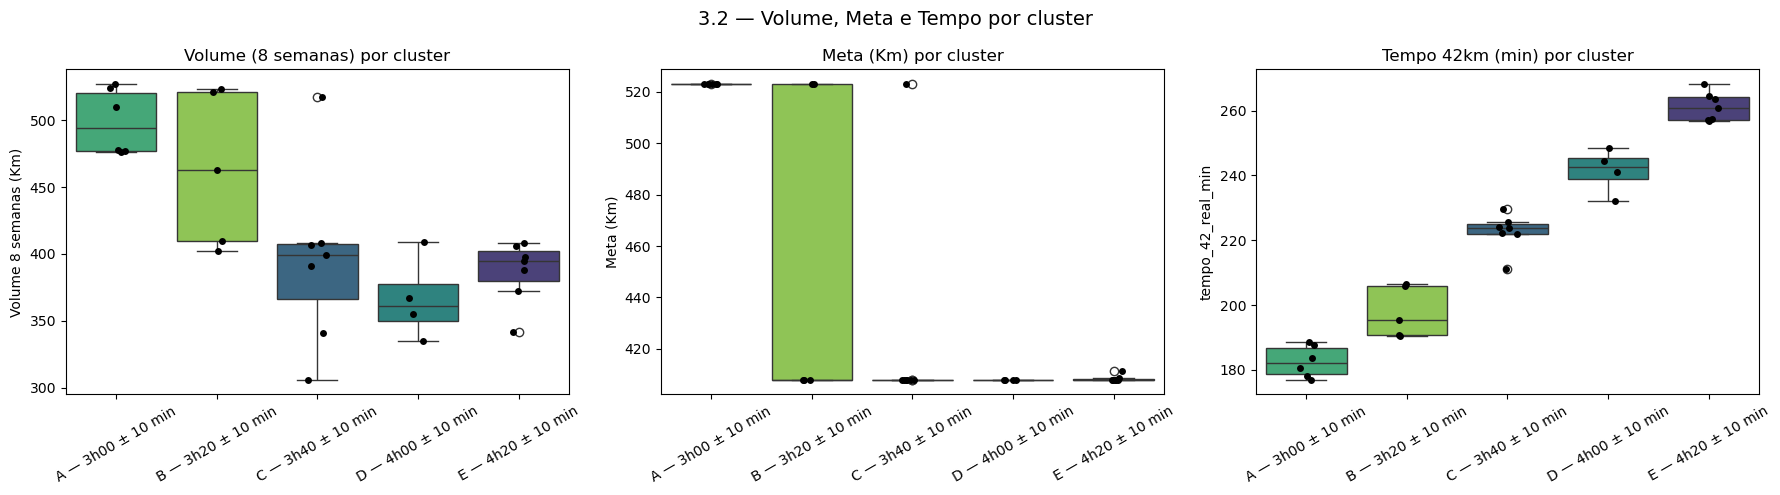

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

cols_plot = ["Volume 8 semanas (Km)", "Meta (Km)", "tempo_42_real_min"]
titulos   = ["Volume (8 semanas)", "Meta (Km)", "Tempo 42km (min)"]

for j, (col, tit) in enumerate(zip(cols_plot, titulos)):
    sns.boxplot(data=df, x="cluster_42km", y=col, order=cluster_order,
                hue="cluster_42km", palette="viridis", legend=False, ax=axs[j])
    sns.stripplot(data=df, x="cluster_42km", y=col, order=cluster_order,
                  color="black", size=5, ax=axs[j])   
    axs[j].set_title(f"{tit} por cluster")
    axs[j].set_xlabel("")
    axs[j].tick_params(axis="x", rotation=30)

fig.suptitle("3.2 — Volume, Meta e Tempo por cluster", fontsize=14)
fig.tight_layout()
plt.show()


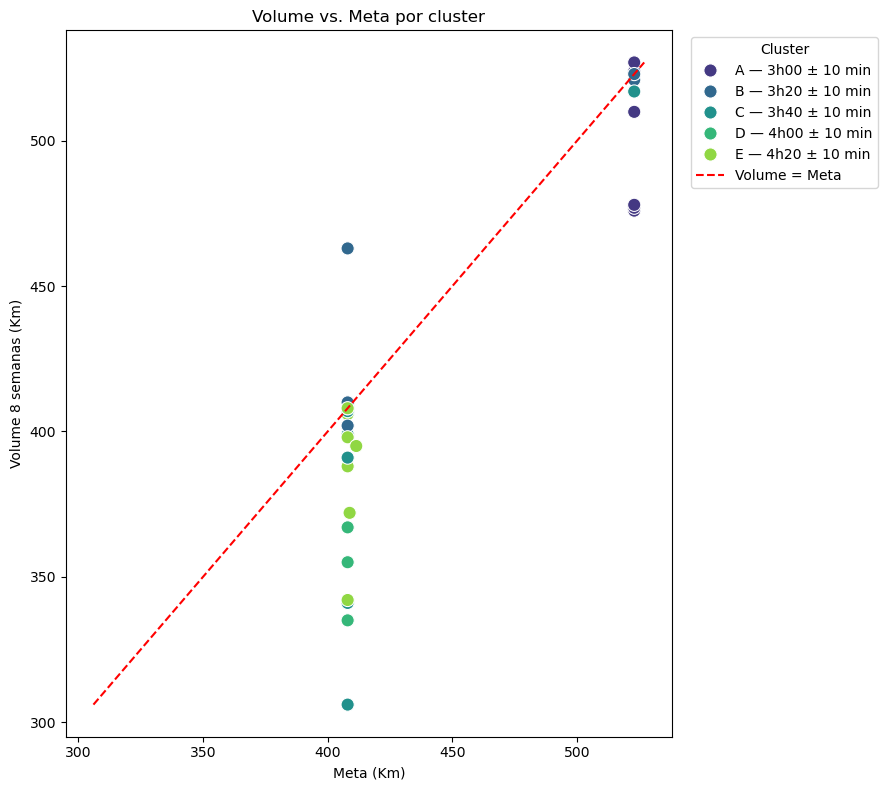

In [17]:
plt.figure(figsize=(9, 8))

sns.scatterplot(data=df, x="Meta (Km)", y="Volume 8 semanas (Km)",
                hue="cluster_42km", hue_order=cluster_order,
                palette="viridis", s=90)

lim_min = min(df["Meta (Km)"].min(), df["Volume 8 semanas (Km)"].min())
lim_max = max(df["Meta (Km)"].max(), df["Volume 8 semanas (Km)"].max())
plt.plot([lim_min, lim_max], [lim_min, lim_max],
         color="red", linestyle="--", label="Volume = Meta")

plt.title("Volume vs. Meta por cluster")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


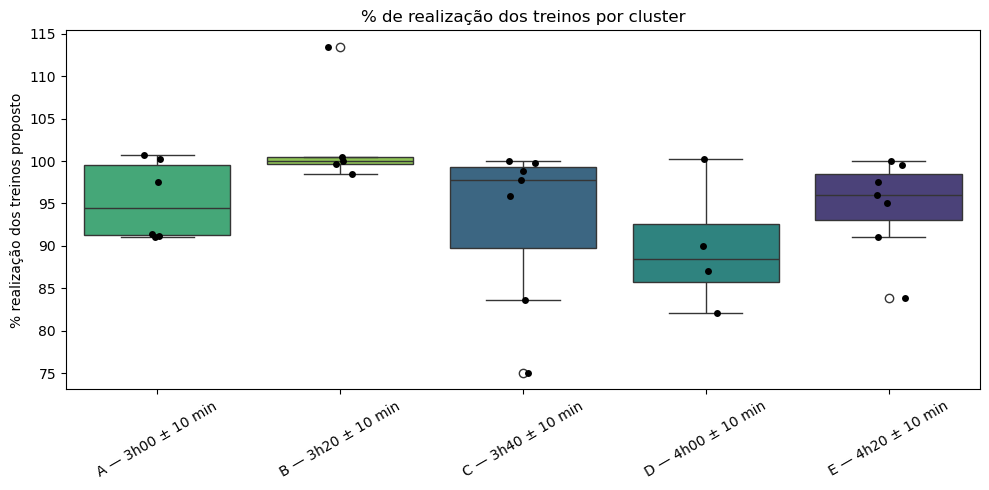

In [19]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x="cluster_42km", y="% realização dos treinos proposto",
            order=cluster_order, hue="cluster_42km",
            palette="viridis", legend=False)
sns.stripplot(data=df, x="cluster_42km", y="% realização dos treinos proposto",
              order=cluster_order, color="black", size=5)

plt.title("% de realização dos treinos por cluster")
plt.xlabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


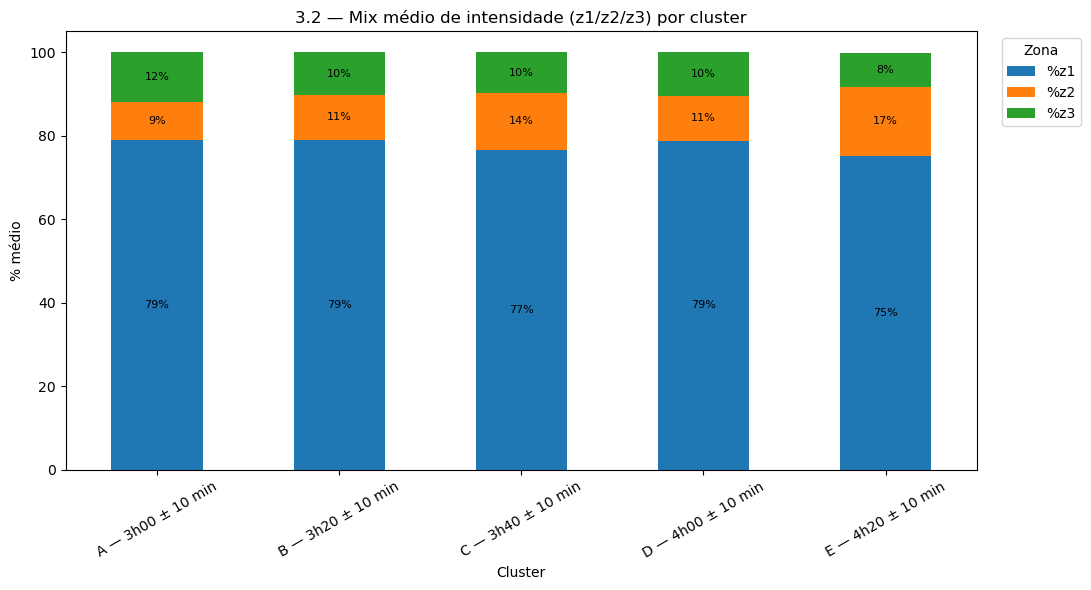

In [20]:
mix_por_cluster = (
    df.groupby("cluster_42km")[["%z1", "%z2", "%z3"]]
      .mean()
      .reindex(cluster_order)
)

ax = mix_por_cluster.plot(kind="bar", stacked=True, figsize=(11, 6))

plt.title("3.2 — Mix médio de intensidade (z1/z2/z3) por cluster")
plt.ylabel("% médio")
plt.xlabel("Cluster")
plt.xticks(rotation=30)
plt.legend(title="Zona", bbox_to_anchor=(1.02, 1), loc="upper left")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", label_type="center", fontsize=8)

plt.tight_layout()
plt.show()


# 3. Fit dos dados aos modelos

## 3.1 Importação das bibliotecas

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from modelos import modelo_sigmoide, modelo_potencia, modelo_hyper

## 3.2 Criação do dataframe responsável pela fittagem

In [23]:
dados_atleta = df.loc[
    :,
    ~df.columns.str.contains(
        r"Grupo|Nome|%|Pace|Tempo|pós|Resul|Volume|Meta|z|tempo|cluster",
        regex=True
    )
]


dados_atleta_x = dados_atleta #dados_atleta.loc[:, ~dados_atleta.columns.str.contains(r"42km")]
dados_atleta_y = dados_atleta["42km"]

---
## 3.3 Criação das variáveis de fittagem (Tempo e Velocidade)

In [22]:
# Dicionário de distâncias em Km
colunas_distancia = {
    '1km_23-abr': 1.0,
    '2km_16-abr': 2.0,
    '3km_21-abr': 3.0,
    '1km_21-mai': 1.0,
    '21km_24-mai': 21.097,
    '42km': 42.195
}


def getFittingData(df_raw:pd.DataFrame, idx_atleta:int) -> (list[float],list[float]):
    tempos_totais = []
    velocidades_totais = []

    df = df_raw.loc[idx_atleta,:]

    for col, dist in colunas_distancia.items():
        if col != '42km' and pd.notna(df[col]): 
            
            segundos = df[col].total_seconds()
            
            if segundos > 0: 
                minutos = segundos / 60
                horas = minutos / 60
                velocidade = dist / horas # Km/h
                
                tempos_totais.append(horas)
                velocidades_totais.append(velocidade)

    T_data = np.array(tempos_totais)
    V_data = np.array(velocidades_totais)

    return T_data,V_data

In [25]:
def fit_models(T_data:list[float], V_data:list[float], parametros_globais:pd.DataFrame,row: int = 0) -> (pd.DataFrame):
    # Chutes iniciais para T em Horas e V em Km/h
    p0_sig = [5.0, 2.0, 1.5, 9.0]
    p0_hyper = [1.0, -0.5, 0.5]

    parametros_globais.loc[row,"Grupo"] = df['Grupo'].iloc[row].astype(str)
    parametros_globais.loc[row,"Nome"] = df['Nome'].iloc[row]

    try:
        log_T = np.log(T_data)
        log_V = np.log(V_data)
        inclinacao, intercepto = np.polyfit(log_T, log_V, 1)
        parametros_globais.loc[row,'Potencia_S'] = np.exp(intercepto)
        parametros_globais.loc[row,'Potencia_E'] = inclinacao + 1.0
    except Exception as e:
        print(f"Erro no fit Potência: {e}")

    # --- Fit Modelo Sigmóide ---
    try:
        bounds_sig = ([0, -10, 0, 0], [30, 10, 10, np.max(V_data) * 1.05])
        popt_sig, _ = optimize.curve_fit(modelo_sigmoide, T_data, V_data, p0=p0_sig, maxfev=10000, bounds=bounds_sig)
        parametros_globais.loc[row,'Sigm_A'] = popt_sig[0]
        parametros_globais.loc[row,'Sigm_k'] = popt_sig[1] 
        parametros_globais.loc[row,'Sigm_t0'] = popt_sig[2] 
        parametros_globais.loc[row,'Sigm_Vbase'] = popt_sig[3]

    except Exception as e:
        print(f"Erro no fit Sigmóide: {e}")

    ## --- Fit Modelo Hiperbólico ---
    try:
        bounds_hyper = ([0, -10, 0.001], [np.max(V_data)*1.1, 10, 24])
        popt_hyper, _ = optimize.curve_fit(modelo_hyper, T_data, V_data, p0=p0_hyper, maxfev=10000, bounds=bounds_hyper)
        parametros_globais.loc[row,'Hyper_a'] = popt_hyper[0] 
        parametros_globais.loc[row,'Hyper_alpha'] = popt_hyper[1] 
        parametros_globais.loc[row,'Hyper_gamma'] = popt_hyper[2]

    except Exception as e:
        print(f"Erro no fit Hyper: {e}")

    return parametros_globais

In [26]:
param_results = pd.DataFrame()

for i in range(dados_atleta_x.shape[0]):
    T_data,V_data = getFittingData(dados_atleta_x,idx_atleta=i)

    param_results = fit_models(T_data=T_data,V_data=V_data,parametros_globais=param_results,row=i)

In [27]:
param_results.head(2)

,Grupo,Nome,Potencia_S,Potencia_E,Sigm_A,Sigm_k,Sigm_t0,Sigm_Vbase,Hyper_a,Hyper_alpha,Hyper_gamma
0,1,S1,10.800749,0.926246,7.574309,6.863954,1.529756e-16,10.415371,14.943396,0.329871,21.06525
1,1,S2,12.958707,0.968822,3.887307,9.416504,1.268753e-11,12.882876,14.036788,0.850892,24.00000


In [28]:
def getHyperParams(row:int,df:pd.DataFrame = param_results) -> pd.Series:
    return df[['Hyper_a','Hyper_alpha','Hyper_gamma']].iloc[row]

def getPowParams(row:int,df:pd.DataFrame = param_results) -> pd.Series:
    return df[['Potencia_S','Potencia_E']].iloc[row]

def getSigParams(row:int,df:pd.DataFrame = param_results) -> pd.Series:
    return df[['Sigm_A','Sigm_k', 'Sigm_t0','Sigm_Vbase']].iloc[row]

In [ ]:
def plotFittedData(row:int,df:pd.DataFrame = param_results,dados_atleta_y:pd.Series = dados_atleta_y) -> (plt.Figure):

    popt_hyper = getHyperParams(row=row, df=param_results)
    popt_pow = getPowParams(row=row, df=param_results)
    popt_sig = getSigParams(row=row, df=param_results)

    T_row, V_row = getFittingData(dados_atleta_x, idx_atleta=row)

    Ts = np.linspace(0.001,6) # 6h

    plt.plot(Ts, modelo_hyper(Ts,*popt_hyper),label="Hyper")
    plt.plot(Ts, modelo_potencia(Ts,*popt_pow),label="Potência")
    plt.plot(Ts, modelo_sigmoide(Ts,*popt_sig),label="Sigmoide")

    tempo_42km = dados_atleta_y.iloc[row].total_seconds() / 3600

    plt.scatter(tempo_42km, 42/tempo_42km,label="42km Real")
    plt.scatter(T_row,V_row,label="Dados Reais", marker="^",color="black")

    plt.legend()
    plt.title(f"Pessoa {df['Nome'].iloc[row]}")
    plt.tight_layout()

    return plt

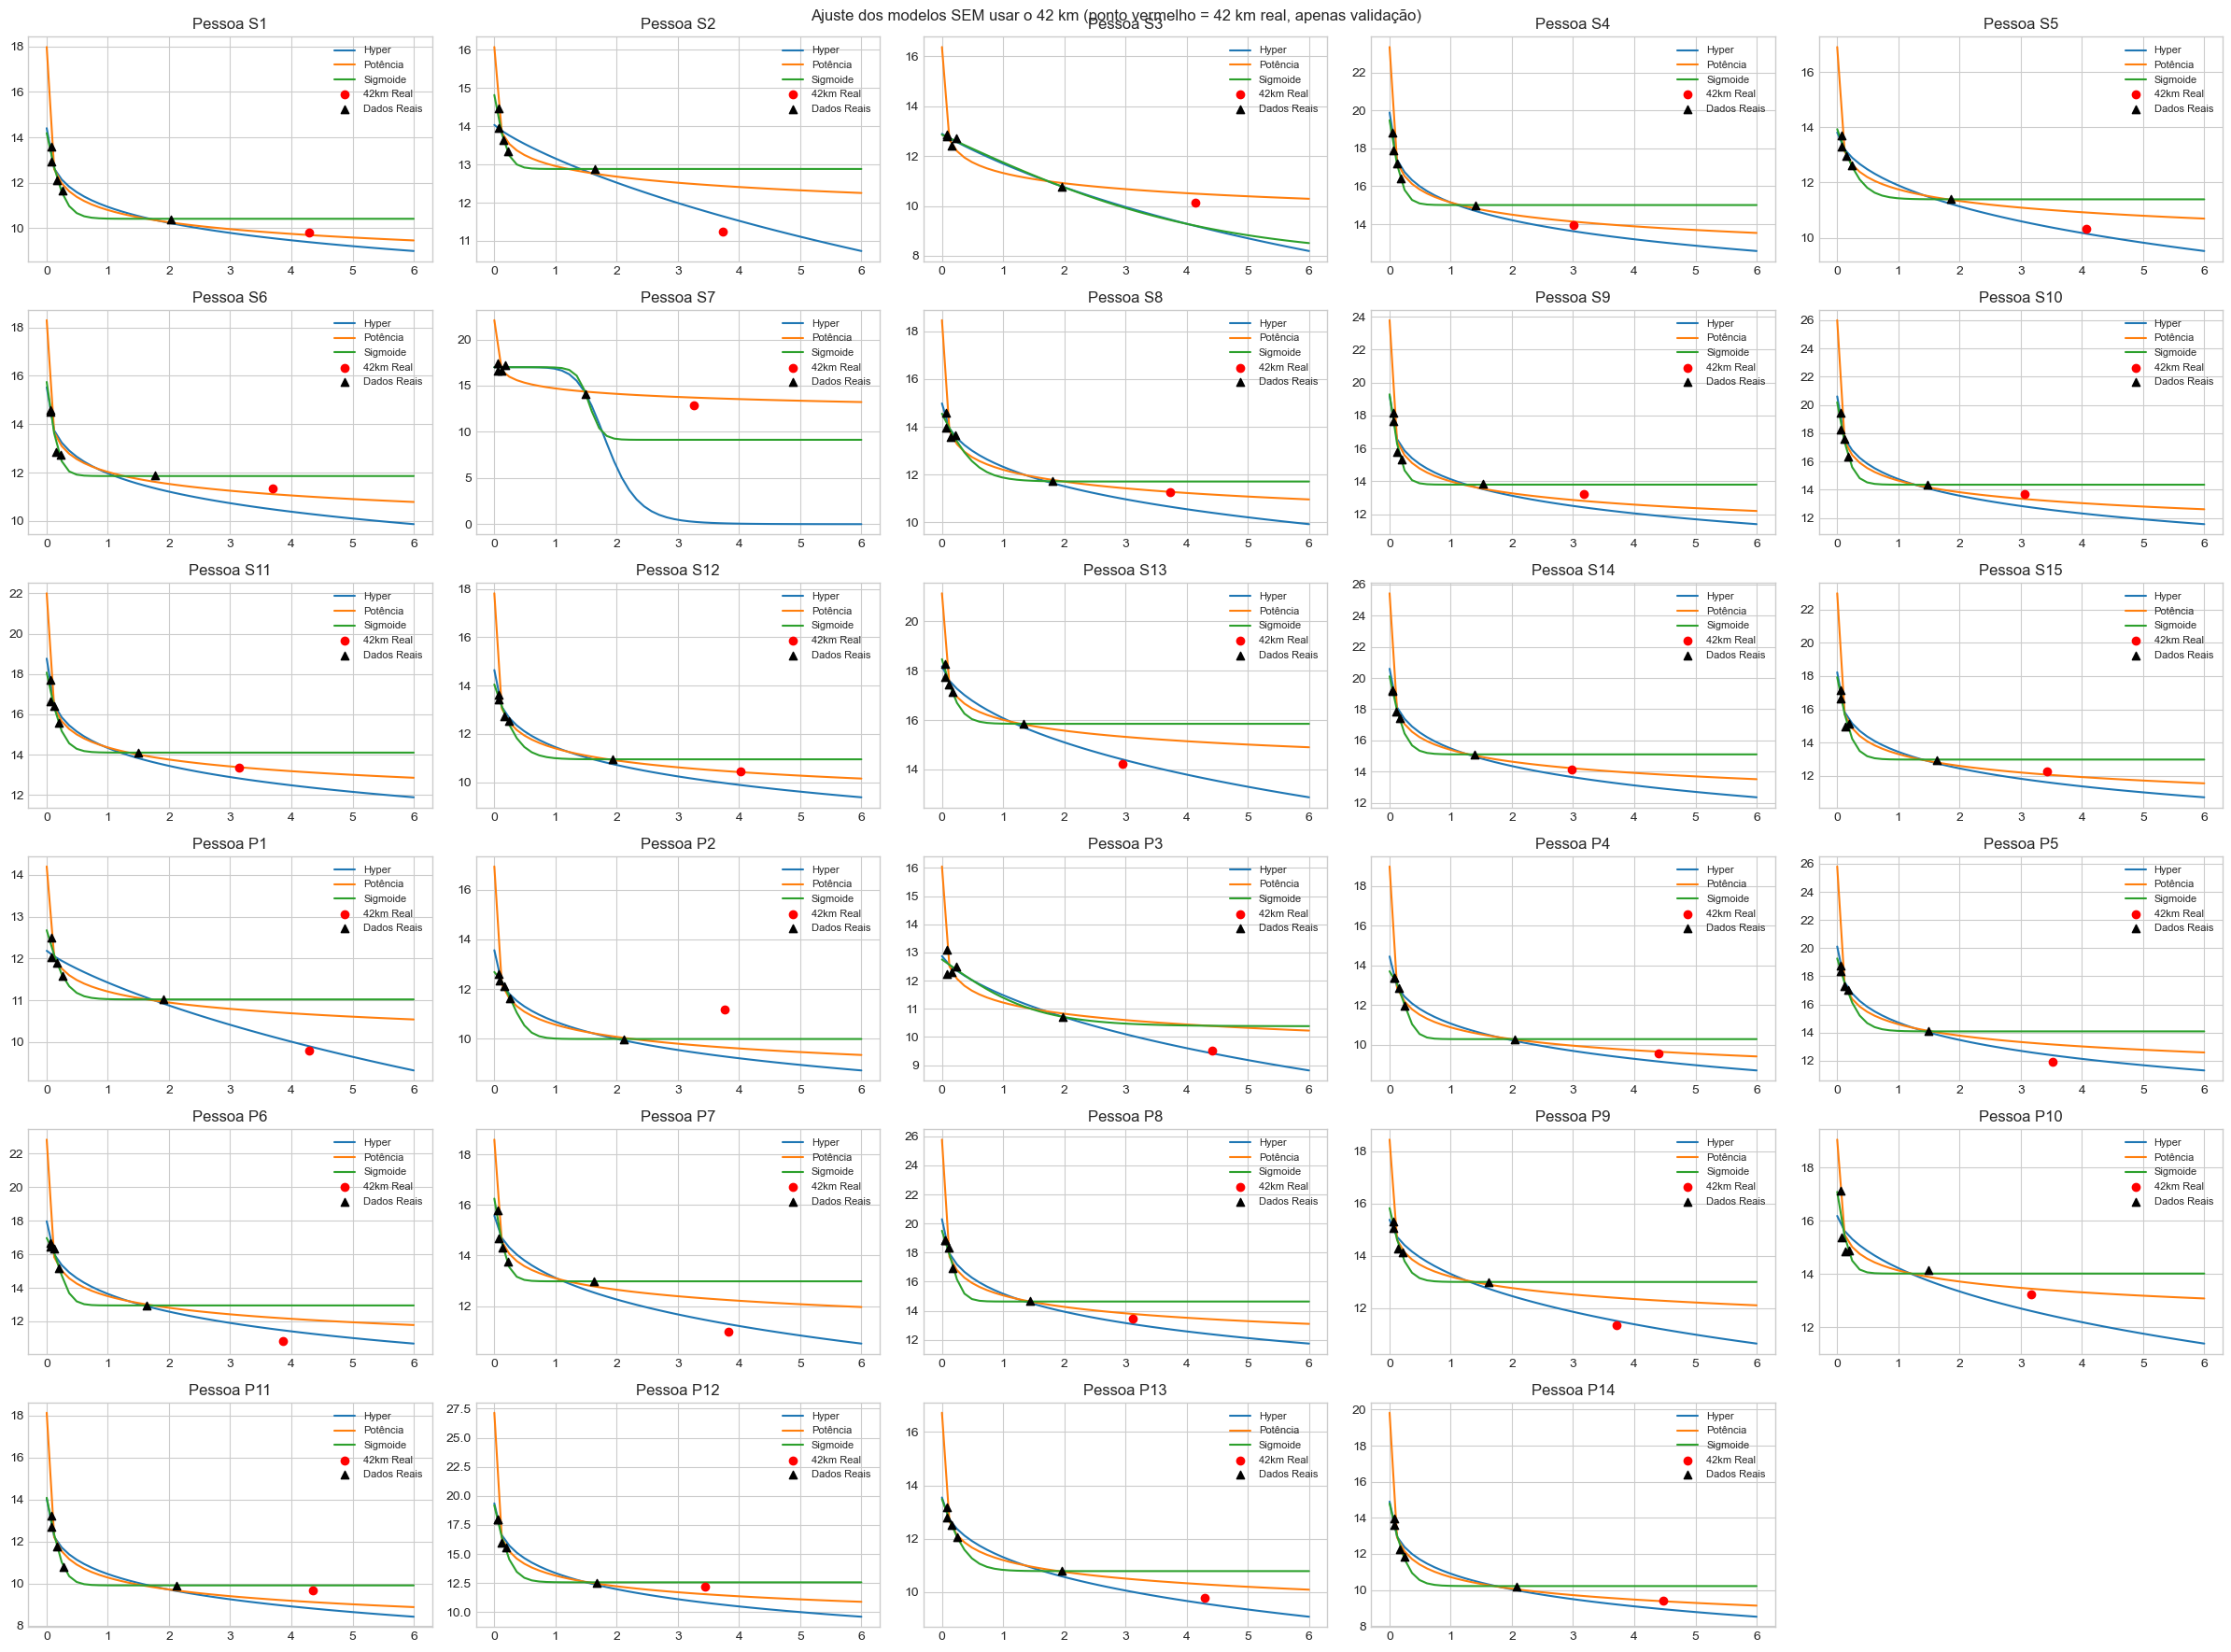

In [30]:
SAVE_PATH = Path.cwd().resolve() / "Results"

fig, axs = plt.subplots(6, 5, figsize=(24, 18))
plt.style.use('seaborn-v0_8-whitegrid')

count = 0

for i in range(6):
    for j in range(5):
        ax = axs[i][j] 
        
        if count == 29:
            ax.remove()
            break

        T_real, V_real = getFittingData(dados_atleta_x, idx_atleta=count)
        
        popt_hyper = getHyperParams(row=count, df=param_results)
        popt_pow = getPowParams(row=count, df=param_results)
        popt_sig = getSigParams(row=count, df=param_results)
        
        Ts = np.linspace(0.001, 6) # 6h
        
        ax.plot(Ts, modelo_hyper(Ts, *popt_hyper), label="Hyper")
        ax.plot(Ts, modelo_potencia(Ts, *popt_pow), label="Potência")
        ax.plot(Ts, modelo_sigmoide(Ts, *popt_sig), label="Sigmoide")
        
        tempo_42km = dados_atleta_y.iloc[count].total_seconds() / 3600
        ax.scatter(tempo_42km, 42/tempo_42km, label="42km Real", color="red", zorder=5)
        ax.scatter(T_real, V_real, label="Dados Reais", marker="^", color="black", zorder=5)
        
        ax.set_title(f"Pessoa {param_results['Nome'].iloc[count]}")
        ax.legend(fontsize=8)
        
        
        count += 1

fig.suptitle("Ajuste dos modelos SEM usar o 42 km (ponto vermelho = 42 km real, apenas validação)")
fig.savefig(SAVE_PATH / "Resultado sem 42km")
fig.tight_layout()
plt.show()

In [ ]:
metricas = {m: {"R2": [], "RMSE": [], "L2": []} for m in ["Sigmoide", "Potencia", "Hyper"]}

for i in range(param_results.shape[0]):
    T_i, V_i = getFittingData(dados_atleta_x, idx_atleta=i)

    popt_sig_i   = getSigParams(row=i).values.astype(float)
    popt_pow_i   = getPowParams(row=i).values.astype(float)
    popt_hyper_i = getHyperParams(row=i).values.astype(float)

    preds = {
        "Sigmoide": modelo_sigmoide(T_i, *popt_sig_i),
        "Potencia": modelo_potencia(T_i, *popt_pow_i),
        "Hyper":    modelo_hyper(T_i, *popt_hyper_i),
    }

    sst = np.sum((V_i - np.mean(V_i)) ** 2)
    n = len(V_i)

    for nome_modelo, v_pred in preds.items():
        erro = V_i - v_pred
        metricas[nome_modelo]["R2"].append(1 - np.sum(erro ** 2) / sst if sst > 0 else np.nan)
        metricas[nome_modelo]["RMSE"].append(np.sqrt(np.sum(erro ** 2) / n))
        metricas[nome_modelo]["L2"].append(np.linalg.norm(erro))

resumo_ajuste = pd.DataFrame({
    m: {
        "R2_medio":   np.nanmean(v["R2"]),
        "RMSE_medio": np.nanmean(v["RMSE"]),
        "L2_medio":   np.nanmean(v["L2"]),
    }
    for m, v in metricas.items()
}).T.round(4)

print("=== Erro de AJUSTE medio nos pontos de treino (NAO usar para escolher modelo) ===")
resumo_ajuste

=== Erro de AJUSTE medio nos pontos de treino (NAO usar para escolher modelo) ===


,R2_medio,RMSE_medio,L2_medio
Sigmoide,0.9500,0.2123,0.4748
Potencia,0.9162,0.2809,0.6281
Hyper,0.8671,0.3663,0.8190


In [ ]:

row_exemplo = 0

popt_sig   = getSigParams(row=row_exemplo).values.astype(float)
popt_pow   = getPowParams(row=row_exemplo).values.astype(float)
popt_hyper = getHyperParams(row=row_exemplo).values.astype(float)

print(f"--- Parâmetros Fitados (atleta {param_results['Nome'].iloc[row_exemplo]}) ---\n")

print(f"Sigmóide:")
print(f"  Amplitude de queda: {popt_sig[0]:.3f} km/h")
print(f"  Taxa de decaimento (k): {popt_sig[1]:.5f}")
print(f"  Ponto de inflexão (t0): {popt_sig[2]:.3f} h")
print(f"  Velocidade Base (Assíntota): {popt_sig[3]:.3f} km/h\n")

print(f"Lei de Potência:")
print(f"  Velocidade Limite (S): {popt_pow[0]:.3f} km/h")
print(f"  Fator de Endurance (E): {popt_pow[1]:.4f}\n")

print(f"Hyper:")
print(f"  Velocidade Máxima (a): {popt_hyper[0]:.3f} km/h")
print(f"  Decaimento (alpha): {popt_hyper[1]:.4f}")
print(f"  Fator de escala (gamma): {popt_hyper[2]:.3f}")

--- Parâmetros Fitados (atleta S1) ---

Sigmóide:
  Amplitude de queda: 7.574 km/h
  Taxa de decaimento (k): 6.86395
  Ponto de inflexão (t0): 0.000 h
  Velocidade Base (Assíntota): 10.415 km/h

Lei de Potência:
  Velocidade Limite (S): 10.801 km/h
  Fator de Endurance (E): 0.9262

Hyper:
  Velocidade Máxima (a): 14.943 km/h
  Decaimento (alpha): 0.3299
  Fator de escala (gamma): 21.065


In [35]:
from scipy.optimize import bisect

DIST_42 = 42.195  

def prever_tempo(modelo, popt, dist=DIST_42, a=0.5, b=12.0):
    f = lambda T: modelo(T, *popt) * T - dist
    try:
        if f(a) * f(b) > 0:     
            return np.nan
        return bisect(f, a, b, xtol=1e-6)
    except Exception:
        return np.nan



In [ ]:
def formatar_tempo(horas):
    if pd.isna(horas):
        return None

    total_segundos = int(round(horas * 3600))

    horas_inteiras, resto = divmod(total_segundos, 3600)
    minutos, segundos = divmod(resto, 60)

    return f"{horas_inteiras}:{minutos:02d}:{segundos:02d}"


registros = []

for i in range(param_results.shape[0]):
    popt_pow = param_results.loc[
        i, ['Potencia_S', 'Potencia_E']
    ].values.astype(float)

    popt_sig = param_results.loc[
        i, ['Sigm_A', 'Sigm_k', 'Sigm_t0', 'Sigm_Vbase']
    ].values.astype(float)

    popt_hyper = param_results.loc[
        i, ['Hyper_a', 'Hyper_alpha', 'Hyper_gamma']
    ].values.astype(float)

    t_real = df['42km'].iloc[i].total_seconds() / 3600

    t_pow = prever_tempo(modelo_potencia, popt_pow)
    t_sig = prever_tempo(modelo_sigmoide, popt_sig)
    t_hyper = prever_tempo(modelo_hyper, popt_hyper)

    registros.append({
        'Nome': param_results.loc[i, 'Nome'],
        'Grupo': param_results.loc[i, 'Grupo'],

        'Tempo_real_h': formatar_tempo(t_real),
        'Pot_prev_h': formatar_tempo(t_pow),
        'Sig_prev_h': formatar_tempo(t_sig),
        'Hyper_prev_h': formatar_tempo(t_hyper),

        'Erro%_Pot': (t_pow - t_real) / t_real * 100,
        'Erro%_Sig': (t_sig - t_real) / t_real * 100,
        'Erro%_Hyper': (t_hyper - t_real) / t_real * 100,
    })

validacao = pd.DataFrame(registros)

validacao.head()

,Nome,Grupo,Tempo_real_h,Pot_prev_h,Sig_prev_h,Hyper_prev_h,Erro%_Pot,Erro%_Sig,Erro%_Hyper
0,S1,1,4:17:02,4:21:16,4:03:04,4:31:25,1.646564,-5.431166,5.595224
1,S2,1,3:44:04,3:22:56,3:16:31,3:36:18,-9.432514,-12.295437,-3.464382
2,S3,1,4:08:30,4:00:51,4:43:16,4:46:56,-3.078269,13.992318,15.467965
3,S4,1,3:00:28,2:59:00,2:48:41,3:06:27,-0.813780,-6.531267,3.311459
4,S5,1,4:04:19,3:51:20,3:42:17,4:10:29,-5.317002,-9.017962,2.523299


In [41]:
resumo = pd.DataFrame({
    'MAPE_% (erro absoluto médio)': {
        'Potencia': validacao['Erro%_Pot'].abs().mean(),
        'Sigmoide': validacao['Erro%_Sig'].abs().mean(),
        'Hyper':    validacao['Erro%_Hyper'].abs().mean(),
    },
    'Vies_% (erro médio com sinal)': {
        'Potencia': validacao['Erro%_Pot'].mean(),
        'Sigmoide': validacao['Erro%_Sig'].mean(),
        'Hyper':    validacao['Erro%_Hyper'].mean(),
    },
}).round(3)

resumo


,MAPE_% (erro absoluto médio),Vies_% (erro médio com sinal)
Potencia,4.969,-1.662
Sigmoide,9.076,-4.384
Hyper,6.588,5.278


In [42]:
SAVE_PATH = Path.cwd().resolve() / "Results"

with pd.ExcelWriter(SAVE_PATH / "validacao_modelos.xlsx") as writer:
    validacao.to_excel(writer, sheet_name="Por_atleta", index=False)
    resumo.to_excel(writer,    sheet_name="Resumo")



In [ ]:
pot_min = pd.to_timedelta(validacao['Pot_prev_h']).dt.total_seconds() / 60
sig_min = pd.to_timedelta(validacao['Sig_prev_h']).dt.total_seconds() / 60
hyper_min = pd.to_timedelta(validacao['Hyper_prev_h']).dt.total_seconds() / 60

validacao['cluster_real'] = df['cluster_42km'].values
validacao['cluster_Pot'] = pot_min.apply(lambda m: classificar_cluster(m, m))
validacao['cluster_Sig'] = sig_min.apply(lambda m: classificar_cluster(m, m))
validacao['cluster_Hyper'] = hyper_min.apply(lambda m: classificar_cluster(m, m))
contagem_clusters = pd.DataFrame({
    'Real': validacao['cluster_real'].value_counts(),
    'Potencia': validacao['cluster_Pot'].value_counts(),
    'Sigmoide': validacao['cluster_Sig'].value_counts(),
    'Hyper': validacao['cluster_Hyper'].value_counts(),
}).fillna(0).astype(int)

contagem_clusters = contagem_clusters.reindex(cluster_order, fill_value=0)

contagem_clusters

,Real,Potencia,Sigmoide,Hyper
A — 3h00 ± 10 min,6,7,9,3
B — 3h20 ± 10 min,5,7,6,6
C — 3h40 ± 10 min,7,4,4,5
D — 4h00 ± 10 min,4,6,6,3
E — 4h20 ± 10 min,7,5,4,11


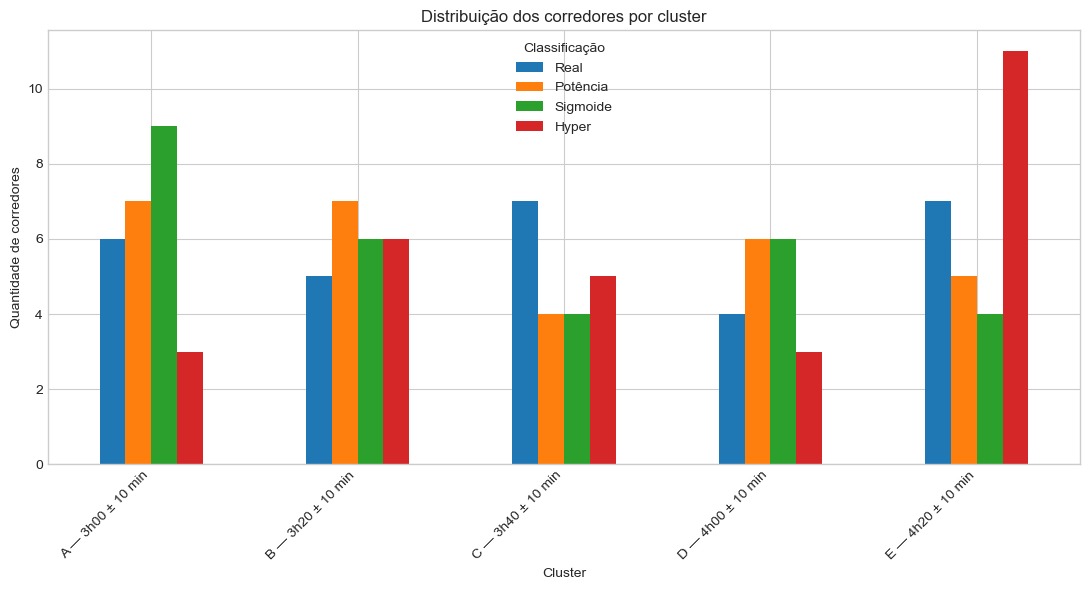

In [47]:
import matplotlib.pyplot as plt
import numpy as np

contagem_clusters = pd.DataFrame({
    'Real': validacao['cluster_real'].value_counts(),
    'Potência': validacao['cluster_Pot'].value_counts(),
    'Sigmoide': validacao['cluster_Sig'].value_counts(),
    'Hyper': validacao['cluster_Hyper'].value_counts(),
}).fillna(0).astype(int)

# Garante a ordem correta dos clusters
contagem_clusters = contagem_clusters.reindex(cluster_order, fill_value=0)

ax = contagem_clusters.plot(
    kind='bar',
    figsize=(11, 6)
)

ax.set_title('Distribuição dos corredores por cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Quantidade de corredores')

plt.xticks(rotation=45, ha='right')
plt.legend(title='Classificação')
plt.tight_layout()
plt.show()

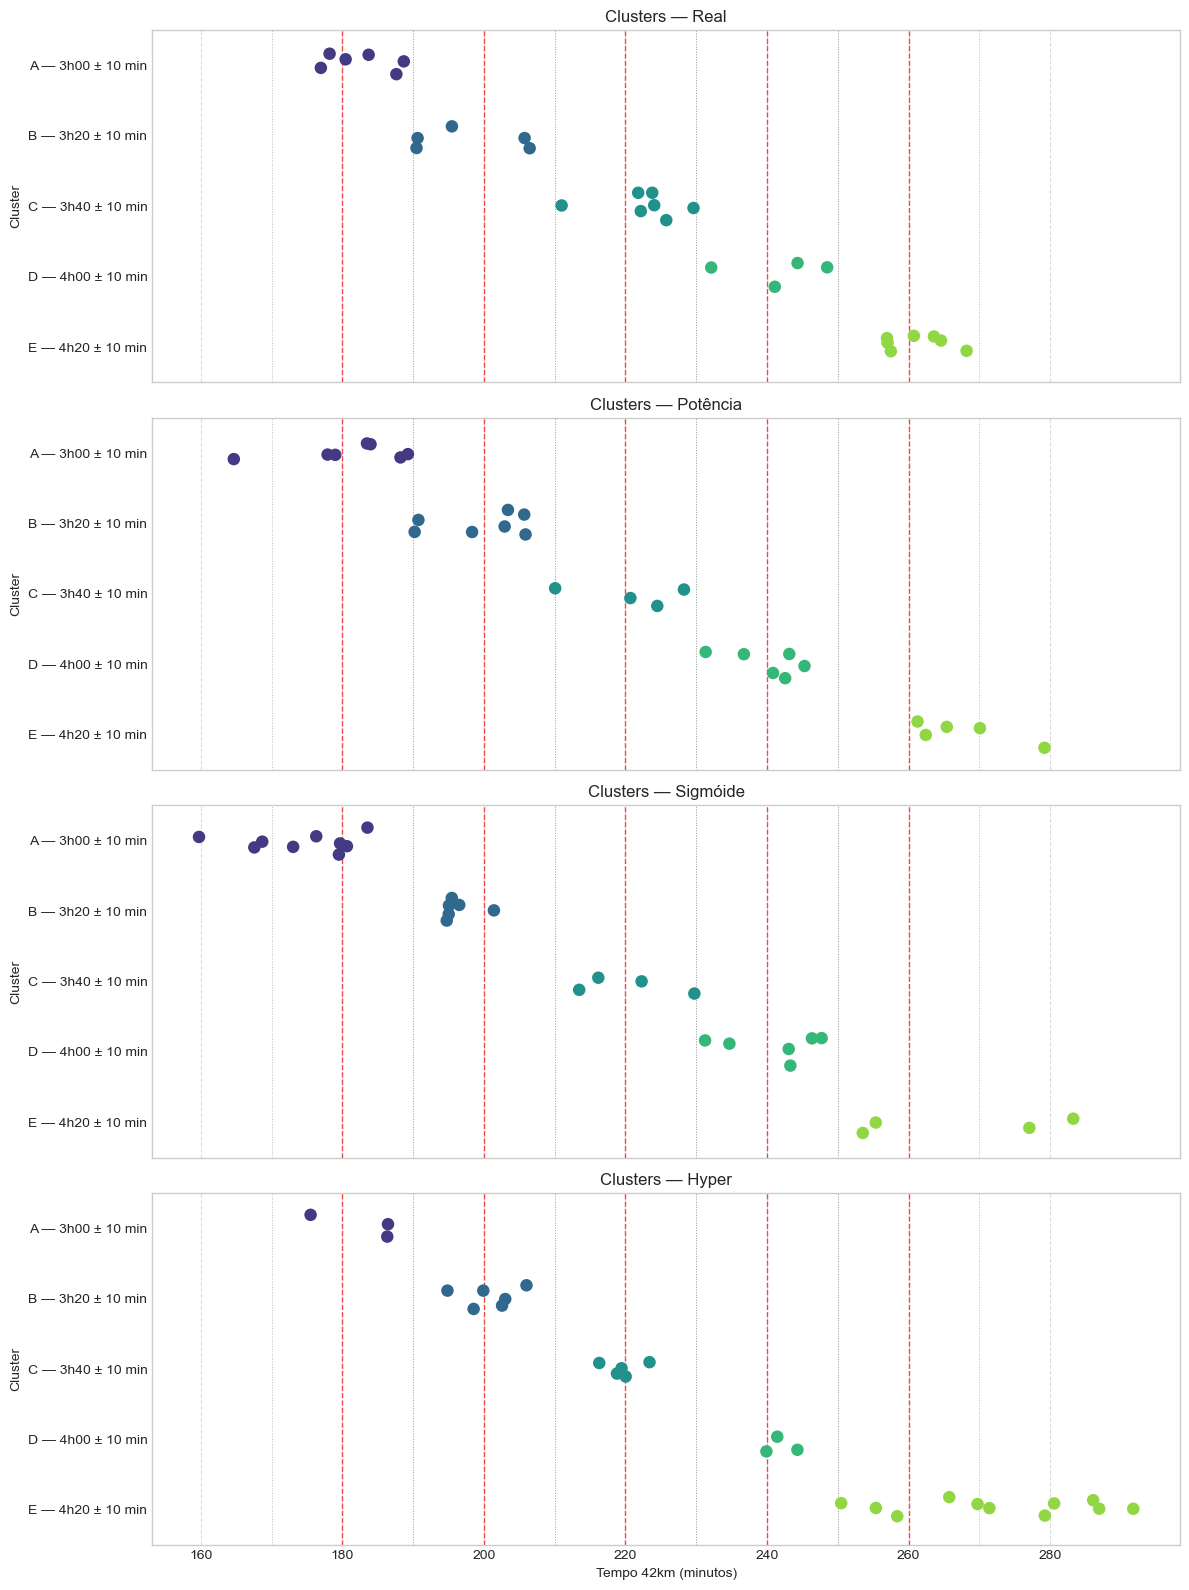

In [49]:
paineis = [
    ("Real",     "Real_min",       "cluster_real"),
    ("Potência", "Pot_prev_min",   "cluster_Pot"),
    ("Sigmóide", "Sig_prev_min",   "cluster_Sig"),
    ("Hyper",    "Hyper_prev_min", "cluster_Hyper"),
]

fig, axs = plt.subplots(len(paineis), 1, figsize=(12, 16), sharex=True)

for ax, (titulo, col_x, col_y) in zip(axs, paineis):
    sns.stripplot(
        data=validacao, x=col_x, y=col_y,
        order=cluster_order, hue=col_y, hue_order=cluster_order,
        jitter=0.2, palette="viridis", s=9, legend=False, ax=ax
    )
    # linhas dos centros (vermelho) e limites ±10 min (cinza) — igual à Seção 2
    for centro in centros_clusters.values():
        ax.axvline(centro,      color='red',  linestyle='--', linewidth=1,   alpha=0.7)
        ax.axvline(centro - 10, color='gray', linestyle=':',  linewidth=0.7, alpha=0.5)
        ax.axvline(centro + 10, color='gray', linestyle=':',  linewidth=0.7, alpha=0.5)

    ax.set_title(f"Clusters — {titulo}")
    ax.set_ylabel("Cluster")
    ax.grid(axis='x', linestyle='--', alpha=0.7)

axs[-1].set_xlabel("Tempo 42km (minutos)")
fig.tight_layout()
plt.show()